In [9]:
import math
import numpy as np
import torch
from torch import nn
import os
import sys

sys.path.insert(0, './d2l-en/pytorch')
from d2l import torch as d2l

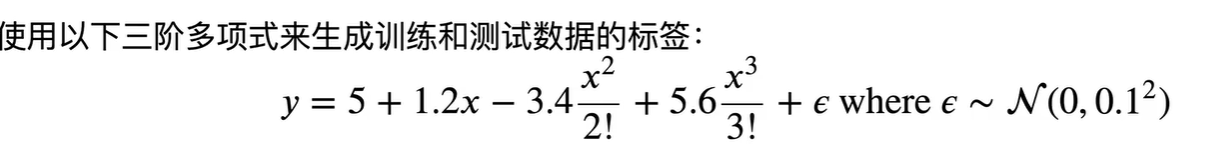

In [10]:
max_degree = 20
n_train, n_test = 100, 100
true_w = np.zeros(max_degree)
true_w[0:4] = np.array([5, 1.2, -3.4, 5.6])

# generates 200 random values from a standard normal distribution (mean=0, std=1)
features = np.random.normal(size=(n_train + n_test, 1))
np.random.shuffle(features)   # randomly reorders input data
poly_features = np.power(features, np.arange(max_degree).reshape(1, -1)) # each row is a power of the number from the feature

# scales each feature by i! to prevent exploding
for i in range(max_degree):
    poly_features[:,i] /= math.gamma(i + 1)
labels = np.dot(poly_features, true_w)  # the label y only concerns the first four because the others are 0
labels += np.random.normal(scale=0.1, size=labels.shape) # adds some noise to the y


In [11]:
true_w, features, poly_features, labels = [
    torch.tensor(x, dtype=torch.float32)
    for x in [true_w, features, poly_features, labels]]

features[0:2], poly_features[:2], labels[:2]

(tensor([[ 0.8562],
         [-0.4241]]),
 tensor([[ 1.0000e+00,  8.5624e-01,  3.6657e-01,  1.0462e-01,  2.2396e-02,
           3.8352e-03,  5.4731e-04,  6.6947e-05,  7.1654e-06,  6.8170e-07,
           5.8369e-08,  4.5435e-09,  3.2419e-10,  2.1353e-11,  1.3059e-12,
           7.4546e-14,  3.9893e-15,  2.0093e-16,  9.5580e-18,  4.3073e-19],
         [ 1.0000e+00, -4.2413e-01,  8.9943e-02, -1.2716e-02,  1.3483e-03,
          -1.1437e-04,  8.0846e-06, -4.8985e-07,  2.5970e-08, -1.2238e-09,
           5.1907e-11, -2.0014e-12,  7.0737e-14, -2.3078e-15,  6.9916e-17,
          -1.9769e-18,  5.2403e-20, -1.3074e-21,  3.0806e-23, -6.8767e-25]]),
 tensor([5.3291, 4.2138]))

In [12]:
def evaluate_loss(net, data_iter, loss):
    metric=d2l.Accumulator(2)
    for X, y in data_iter: 
        out = net(X)
        y = y.reshape(out.shape)
        l = loss(out, y)
        metric.add(l.sum(), l.numel())
    return metric[0] / metric[1]

In [13]:
def train(train_features, test_features, train_labels, test_labels, num_epochs=400):
    loss = nn.MSELoss()
    input_shape = train_features.shape[-1]
    net = nn.Sequential(nn.Linear(input_shape, 1, bias=False))
    batch_size = min(10, train_labels.shape[0])
    train_iter = d2l.load_array((train_features, train_labels.reshape(-1, 1)), batch_size)
    test_iter = d2l.load_array((test_features, test_labels.reshape(-1, 1)), batch_size, is_train=False)
    trainer = torch.optim.SGD(net.parameters(), lr = 0.01)
    animator = d2l.Animator(xlabel='epoch', ylabel='loss', yscale='log', xlim=[1, num_epochs], ylim=[1e-3, 1e2], legend=['train', 'test'])

    for epoch in range(num_epochs):
        d2l.train_epoch_ch3(net, train_iter, loss, trainer)
        if epoch == 0 or (epoch + 1) % 20 == 0:
            animator.add(epoch + 1, (evaluate_loss(net, train_iter, loss), evaluate_loss(net, test_iter, loss)))
            
    print('weight: ', net[0].weight.data.numpy())                                                              

weight:  [[ 5.009945   1.2883829 -3.452906   5.38225  ]]


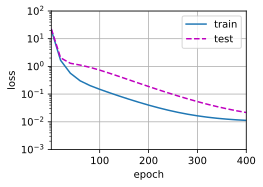

In [14]:
train(poly_features[:n_train, :4], poly_features[n_train:, :4], labels[:n_train], labels[n_train:])

weight:  [[3.3016174 3.5548384]]


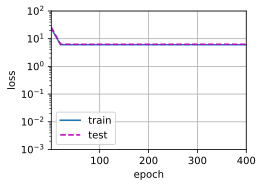

In [16]:
train(poly_features[:n_train, :2], poly_features[n_train:, :2], labels[:n_train], labels[n_train:])

weight:  [[ 4.9153538e+00  1.4395878e+00 -2.9857721e+00  4.6715083e+00
  -1.5539079e+00  1.2481437e+00 -2.1597853e-01  2.7583638e-01
   4.3364387e-02  1.6565265e-01  7.0491642e-02  1.5080409e-01
  -7.8766666e-02  6.0118321e-02  9.3828544e-02 -8.8349722e-02
  -1.5518185e-01  1.9149244e-02  6.2801123e-02  3.3110231e-03]]


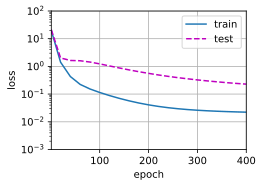

In [17]:
train(poly_features[:n_train, :], poly_features[n_train:, :], labels[:n_train], labels[n_train:])